In [1]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph, START, END
import random

In [4]:
answer = 10

In [2]:
class AgentState(TypedDict):
    name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int


In [17]:
def setup_node(state: AgentState) -> AgentState:
    state['guesses'] = []
    state['attempts'] = 0
    state['lower_bound'] = 1
    state['upper_bound'] = 20

    return state
def guess_node(state:AgentState) -> AgentState:
    guess = random.randint(state['lower_bound'], state['upper_bound'])
    state['guesses'].append(guess)
    state['attempts'] += 1

    return state

def hint_node(state:AgentState) -> AgentState:
    current_answer = state['guesses'][-1] if state['guesses'] else None

    if answer > current_answer:
        print(f"Higher! The answer is higher than {current_answer}.")
        state['lower_bound'] = current_answer + 1
    else:
        print(f"Lower! The answer is lower than {current_answer}.")
        state['upper_bound'] = current_answer - 1
    return state

    

In [18]:
def hint_router(state: AgentState) -> str:
    if state['attempts'] >= 7:
        return 'exit'
    elif answer == state['guesses'][-1]:
        return 'exit'
    else:
        return 'continue'

In [19]:
graph = StateGraph(AgentState)
graph.add_node("setup", setup_node)
graph.add_node('guess', guess_node)
graph.add_node('hint', hint_node)

graph.add_edge(START, "setup")
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")

graph.add_conditional_edges("hint", hint_router, {
    'exit': END,
    'continue': "guess"
})

app = graph.compile()

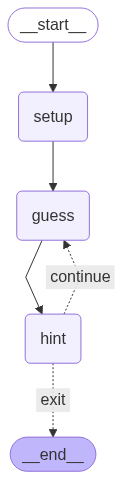

In [20]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png())) 

In [21]:
app.invoke(AgentState(
    name="Jimmy",
    guesses=[],
    attempts=0,
    lower_bound=1,
    upper_bound=20
))

Lower! The answer is lower than 15.
Higher! The answer is higher than 8.
Lower! The answer is lower than 13.
Lower! The answer is lower than 10.


{'name': 'Jimmy',
 'guesses': [15, 8, 13, 10],
 'attempts': 4,
 'lower_bound': 9,
 'upper_bound': 9}